# DTI pActivity Distribution

Visualize the distribution of pActivity values used in the DTI protein-supervised pre-training task and overlay the **GRAM-DTI 3-class discretization** (Appendix A, Eq. 8 of https://arxiv.org/pdf/2509.21971).

**Definition.** `pY = -log10(Y_M) = 9 - log10(Y_nM)`; higher pY = stronger binding.

**GRAM-DTI bins** (on raw IC50):

| class | IC50 range | pY range | meaning |
|---|---|---|---|
| 0 | `IC50 < 10 uM`             | `pY > 5`     | effective   |
| 1 | `10 uM <= IC50 <= 1000 uM` | `3 <= pY <= 5` | moderate    |
| 2 | `IC50 > 1000 uM`           | `pY < 3`     | ineffective |

Sources:
- **Raw TDC pool**: `data/dti-scratch-v2/protein-drug-trainonly.csv` (~4.3 M rows before filter, all TDC-DTI train splits pooled, KIBA included).
- **Training file**: `data/dti-processed/dti_pactivity_esmc_100k.csv` (z-scored pY; recovered via `..._norm_stats.pt`).

In [11]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

RAW_CSV   = Path('/home/shpark/prj-molrepr/graphium/data/dti-scratch-v2/protein-drug-trainonly.csv')
TRAIN_CSV = Path('/home/shpark/prj-molrepr/graphium/data/dti-processed/dti_pactivity_esmc_100k.csv')
TRAIN_STATS = Path('/home/shpark/prj-molrepr/graphium/data/dti-processed/dti_pactivity_esmc_100k_norm_stats.pt')

# GRAM-DTI thresholds (paper Appendix A)
# class 0: pY > 5   (IC50 < 10 uM,     effective)
# class 1: 3 <= pY <= 5  (10 uM <= IC50 <= 1000 uM, moderate)
# class 2: pY < 3   (IC50 > 1000 uM,   ineffective)
PY_HIGH = 5.0   # boundary between class 0 and class 1
PY_LOW  = 3.0   # boundary between class 1 and class 2

def discretize(pY):
    pY = np.asarray(pY)
    cls = np.full(pY.shape, 1, dtype=np.int64)  # default = moderate
    cls[pY > PY_HIGH] = 0   # effective
    cls[pY < PY_LOW]  = 2   # ineffective
    return cls

CLASS_NAMES = ['effective (pY>5)', 'moderate (3-5)', 'ineffective (pY<3)']
CLASS_COLORS = ['#2E86AB', '#E9C46A', '#A23B72']

## 1. Raw TDC pool

Load only the columns we need (`Y`, `dti_dataset`) from the 845 MB raw CSV. KIBA is dropped (KIBA scores are not nM, so pY is not comparable); invalid `Y <= 0` rows are dropped.

In [12]:
raw = pd.read_csv(RAW_CSV, usecols=['Y', 'dti_dataset'], low_memory=False)
print(f'Rows loaded: {len(raw):,}')
print(f'Datasets: {raw["dti_dataset"].value_counts().to_dict()}')

n_before = len(raw)
raw = raw[raw['dti_dataset'] != 'kiba'].copy()
print(f'After dropping KIBA:  {n_before:,} -> {len(raw):,}')

n_before = len(raw)
raw = raw[raw['Y'] > 0].copy()
print(f'After dropping Y<=0:  {n_before:,} -> {len(raw):,}')

raw['pY'] = 9.0 - np.log10(raw['Y'].values)
raw['pY'] = raw['pY'].clip(0.0, 14.0)   # match prep script
raw['class'] = discretize(raw['pY'].values)

print()
print(raw[['pY']].describe().round(3).T)

Rows loaded: 1,149,814
Datasets: {'bindingdb_ic50': 637477, 'bindingdb_ki': 240237, 'bindingdb_patent': 138558, 'kiba': 82360, 'bindingdb_kd': 33141, 'davis': 18041}
After dropping KIBA:  1,149,814 -> 1,067,454
After dropping Y<=0:  1,067,454 -> 1,067,272

        count   mean    std  min    25%    50%    75%   max
pY  1067272.0  6.491  1.534  2.0  5.208  6.489  7.638  14.0


## 2. Overall pY distribution + GRAM-DTI cuts

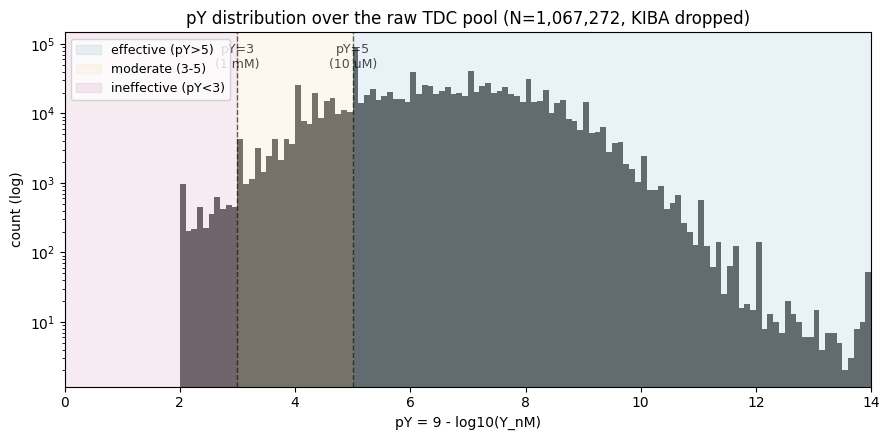

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))

bins = np.linspace(0, 14, 141)   # 0.1-wide bins
ax.hist(raw['pY'], bins=bins, color='#444', alpha=0.8, edgecolor='none')

# Shade the 3 GRAM-DTI classes
ax.axvspan(PY_HIGH, 14, alpha=0.10, color=CLASS_COLORS[0], label=CLASS_NAMES[0])
ax.axvspan(PY_LOW, PY_HIGH, alpha=0.10, color=CLASS_COLORS[1], label=CLASS_NAMES[1])
ax.axvspan(0,      PY_LOW,  alpha=0.10, color=CLASS_COLORS[2], label=CLASS_NAMES[2])
ax.axvline(PY_HIGH, ls='--', color='k', lw=1, alpha=0.6)
ax.axvline(PY_LOW,  ls='--', color='k', lw=1, alpha=0.6)

ax.set_yscale('log')
ymax = ax.get_ylim()[1]
ax.text(PY_HIGH, ymax*0.7, 'pY=5\n(10 uM)', ha='center', va='top', fontsize=9, alpha=0.7)
ax.text(PY_LOW,  ymax*0.7, 'pY=3\n(1 mM)',  ha='center', va='top', fontsize=9, alpha=0.7)

ax.set_xlabel('pY = 9 - log10(Y_nM)')
ax.set_ylabel('count (log)')
ax.set_title(f'pY distribution over the raw TDC pool (N={len(raw):,}, KIBA dropped)')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(0, 14)
plt.tight_layout()
plt.show()

### Class counts and GRAM-DTI weights

Paper uses weighted cross-entropy with `w_c = N_total / (C * N_c)` (balanced inverse-frequency).
Note how imbalanced the pool is.

In [14]:
def class_table(cls, total=None, label=''):
    if total is None:
        total = len(cls)
    C = 3
    rows = []
    for k, name in enumerate(CLASS_NAMES):
        n_k = int((cls == k).sum())
        pct = 100 * n_k / total if total else 0.0
        w_k = total / (C * n_k) if n_k > 0 else float('inf')
        rows.append({'class': k, 'name': name, 'count': n_k,
                     'pct': f'{pct:.2f}%', 'weight w_c': round(w_k, 4)})
    df = pd.DataFrame(rows)
    if label:
        print(f'--- {label} (N={total:,}) ---')
    return df

class_table(raw['class'].values, label='Raw TDC pool')

--- Raw TDC pool (N=1,067,272) ---


,class,name,count,pct,weight w_c
0,0,effective (pY>5),830519,77.82%,0.4284
1,1,moderate (3-5),232359,21.77%,1.5311
2,2,ineffective (pY<3),4394,0.41%,80.9643


## 3. Per-dataset breakdown

Different source datasets (BindingDB_IC50 vs BindingDB_Ki vs BindingDB_Kd vs DAVIS vs patent) populate different regions of pY. This matters because the GRAM-DTI paper thresholds were set for **IC50 specifically**.

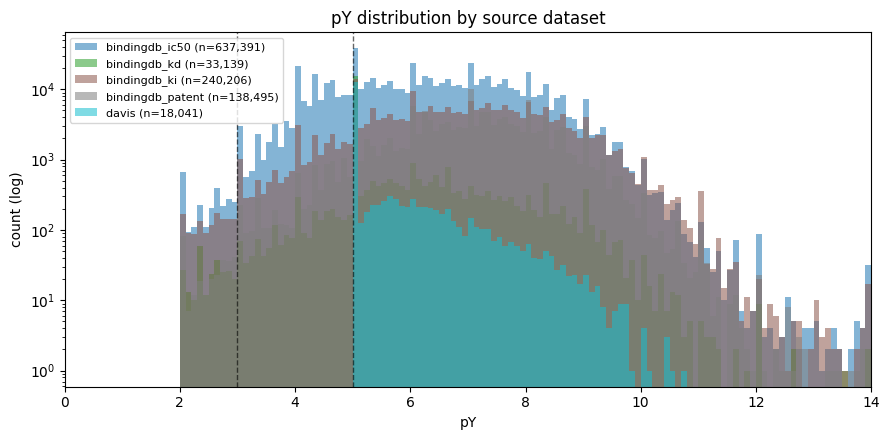

In [15]:
datasets = sorted(raw['dti_dataset'].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(datasets)))

fig, ax = plt.subplots(figsize=(9, 4.5))
for ds, c in zip(datasets, colors):
    sub = raw.loc[raw['dti_dataset'] == ds, 'pY']
    ax.hist(sub, bins=bins, alpha=0.55, color=c,
            label=f'{ds} (n={len(sub):,})', histtype='stepfilled', edgecolor='none')

ax.axvline(PY_HIGH, ls='--', color='k', lw=1, alpha=0.6)
ax.axvline(PY_LOW,  ls='--', color='k', lw=1, alpha=0.6)
ax.set_yscale('log')
ax.set_xlabel('pY')
ax.set_ylabel('count (log)')
ax.set_title('pY distribution by source dataset')
ax.legend(loc='upper left', fontsize=8)
ax.set_xlim(0, 14)
plt.tight_layout()
plt.show()

In [16]:
rows = []
for ds in datasets:
    sub = raw[raw['dti_dataset'] == ds]
    cls = sub['class'].values
    rows.append({
        'dataset':     ds,
        'N':           len(sub),
        'pY mean':     round(sub['pY'].mean(), 3),
        'pY std':      round(sub['pY'].std(),  3),
        'class 0 (effective) %':   f'{100*(cls==0).mean():.1f}%',
        'class 1 (moderate)  %':   f'{100*(cls==1).mean():.1f}%',
        'class 2 (ineffective) %': f'{100*(cls==2).mean():.1f}%',
    })
pd.DataFrame(rows).set_index('dataset')

,N,pY mean,pY std,class 0 (effective) %,class 1 (moderate) %,class 2 (ineffective) %
dataset,,,,,,
bindingdb_ic50,637391,6.316,1.527,75.2%,24.4%,0.4%
bindingdb_kd,33139,5.785,1.336,46.2%,53.1%,0.8%
bindingdb_ki,240206,6.826,1.564,85.3%,14.2%,0.5%
bindingdb_patent,138495,7.020,1.322,91.1%,8.7%,0.2%
davis,18041,5.412,0.836,29.0%,71.0%,0.0%


## 4. Training file (filtered 100 K, actually used by the model)

The CSV stores **z-scored pY**; we de-normalize using the saved mean/std to compare with the raw pool.
This is the subset the current `dti_pactivity` task sees during training (5,222-protein stratified + SMILES-novel 100 K sample).

In [17]:
stats = torch.load(TRAIN_STATS, map_location='cpu', weights_only=False)
pY_mean = float(stats['pY_mean'])
pY_std  = float(stats['pY_std'])
print(f'Saved pY normalization: mean={pY_mean:.4f}, std={pY_std:.4f}')

train = pd.read_csv(TRAIN_CSV, usecols=['pY'])
train['pY_raw'] = train['pY'].values * pY_std + pY_mean
train['class']  = discretize(train['pY_raw'].values)
print(f'Training set N = {len(train):,}')
print(train[['pY_raw']].describe().round(3).T)

Saved pY normalization: mean=6.5691, std=1.5363
Training set N = 99,597
          count   mean    std  min    25%    50%    75%   max
pY_raw  99597.0  6.569  1.536  2.0  5.367  6.638  7.721  14.0


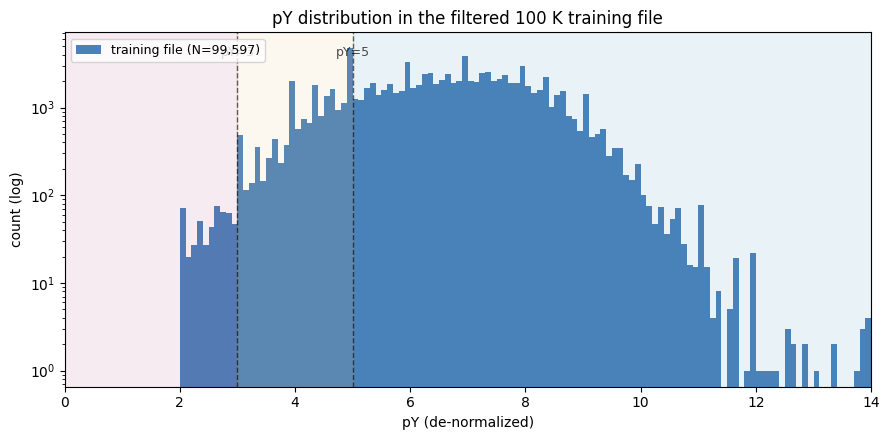

In [18]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(train['pY_raw'], bins=bins, color='#2b6cb0', alpha=0.85,
        edgecolor='none', label=f'training file (N={len(train):,})')

ax.axvspan(PY_HIGH, 14,  alpha=0.10, color=CLASS_COLORS[0])
ax.axvspan(PY_LOW, PY_HIGH, alpha=0.10, color=CLASS_COLORS[1])
ax.axvspan(0,      PY_LOW,  alpha=0.10, color=CLASS_COLORS[2])
ax.axvline(PY_HIGH, ls='--', color='k', lw=1, alpha=0.6)
ax.axvline(PY_LOW,  ls='--', color='k', lw=1, alpha=0.6)

ax.set_yscale('log')
ymax = ax.get_ylim()[1]
ax.text(PY_HIGH, ymax*0.7, 'pY=5', ha='center', va='top', fontsize=9, alpha=0.7)
ax.text(PY_LOW,  ymax*0.7, 'pY=3', ha='center', va='top', fontsize=9, alpha=0.7)

ax.set_xlabel('pY (de-normalized)')
ax.set_ylabel('count (log)')
ax.set_title('pY distribution in the filtered 100 K training file')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(0, 14)
plt.tight_layout()
plt.show()

In [19]:
class_table(train['class'].values, label='Training file (dti_pactivity_esmc_100k.csv)')

--- Training file (dti_pactivity_esmc_100k.csv) (N=99,597) ---


,class,name,count,pct,weight w_c
0,0,effective (pY>5),80208,80.53%,0.4139
1,1,moderate (3-5),18902,18.98%,1.7564
2,2,ineffective (pY<3),487,0.49%,68.1704


## 5. Raw pool vs training file, overlaid (density)

Any distributional shift from the 1-per-protein + novel-SMILES filter is visible as a divergence between the two curves.

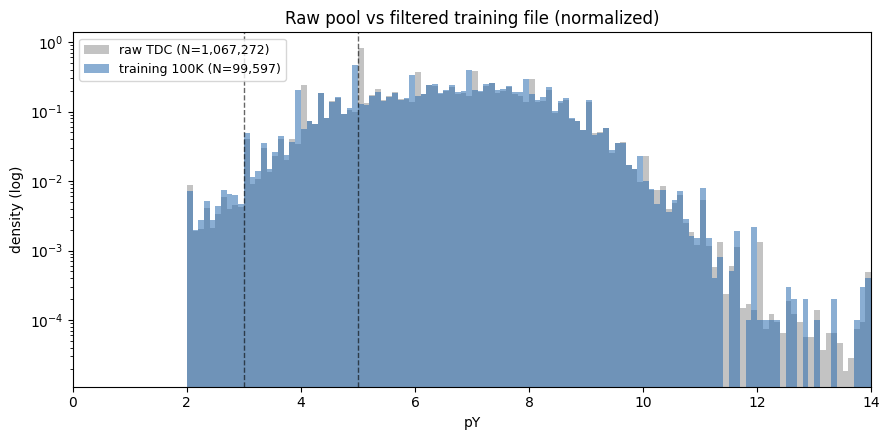

In [20]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(raw['pY'],       bins=bins, density=True, alpha=0.5, color='#888',    label=f'raw TDC (N={len(raw):,})',   edgecolor='none')
ax.hist(train['pY_raw'], bins=bins, density=True, alpha=0.55, color='#2b6cb0', label=f'training 100K (N={len(train):,})', edgecolor='none')

ax.axvline(PY_HIGH, ls='--', color='k', lw=1, alpha=0.6)
ax.axvline(PY_LOW,  ls='--', color='k', lw=1, alpha=0.6)
ax.set_yscale('log')
ax.set_xlabel('pY')
ax.set_ylabel('density (log)')
ax.set_title('Raw pool vs filtered training file (normalized)')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(0, 14)
plt.tight_layout()
plt.show()